/usr/local/anaconda/lib/python3.6/site-packages/PIL/Image.py:976: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


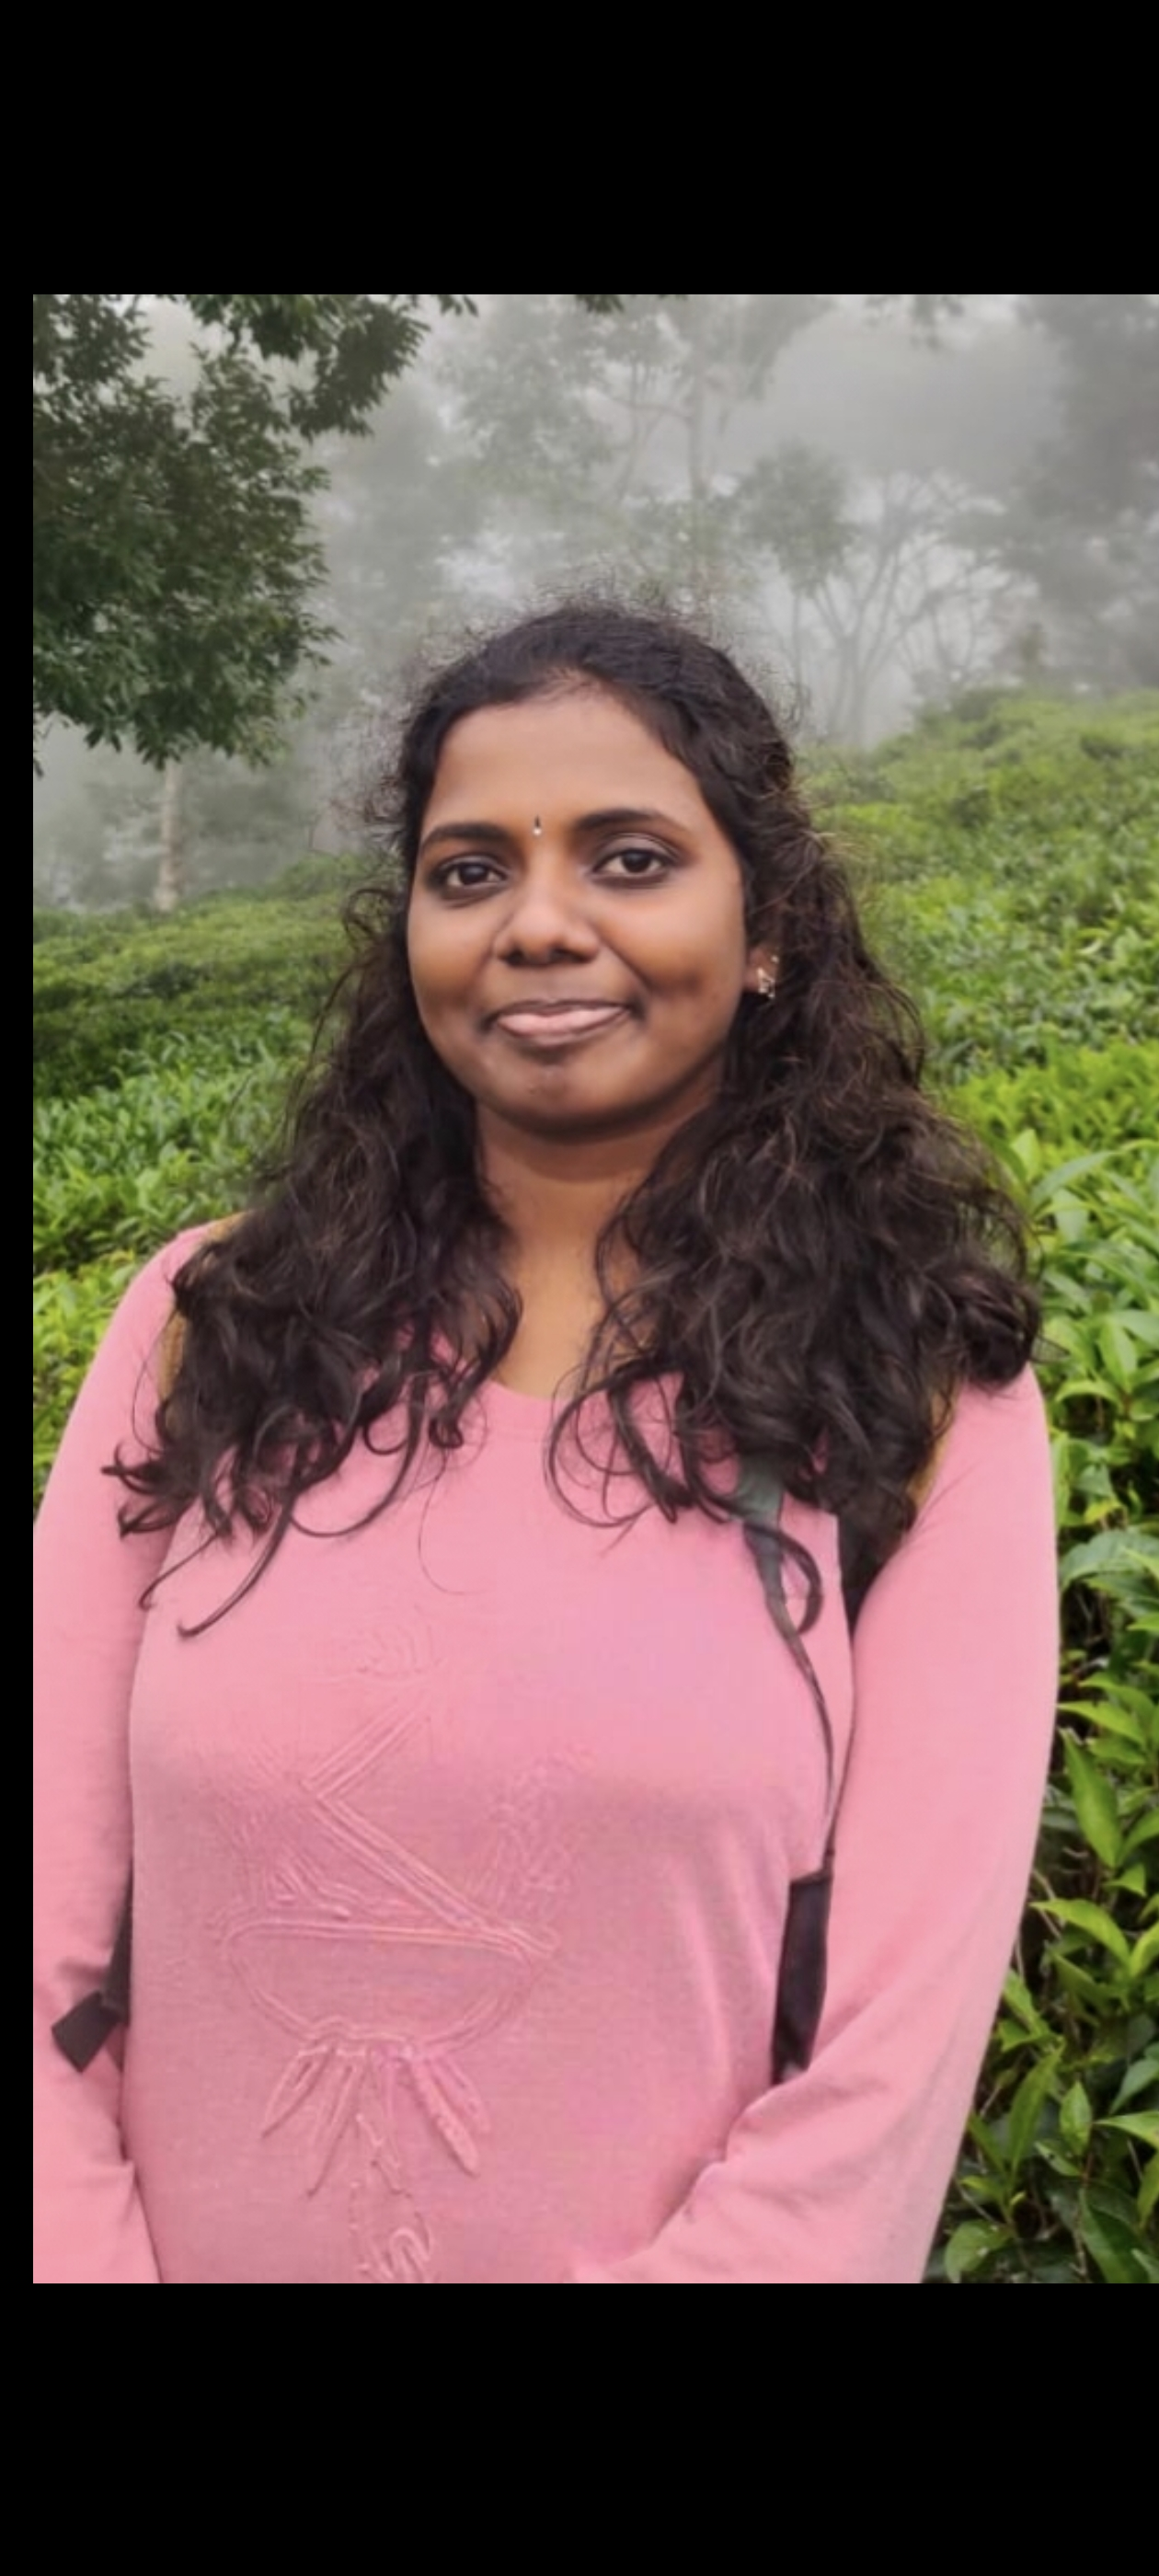

In [1]:
# Face Recognition

import face_recognition
import os
import numpy as np
from IPython.display import Image

def load_images(known_images_dir):
    known_encodings = []
    known_images = []
    
    for file in os.listdir(known_images_dir):
        filename = os.fsdecode(file)
        image = face_recognition.load_image_file(os.path.join(known_images_dir, filename))
        
        enc = face_recognition.face_encodings(image)
        if len(enc) > 0:
            known_encodings.append(enc[0])
            known_images.append(filename)
            
    return (known_encodings, known_images)  

def calculate_face_distance(known_encodings, unknown_img_path, cutoff=0.5, num_results=4):
    image_to_test = face_recognition.load_image_file(unknown_img_path)
    image_to_test_encoding = face_recognition.face_encodings(image_to_test)[0]
    face_distances = face_recognition.face_distance(known_encodings, image_to_test_encoding)
    return (unknown_img_path, known_images[face_distances.argmin()])

known_encodings, known_images = load_images("/cxldata/projects/lookalikeceleb/images")
original_image = "../lookalikeceleb/myimage.jpg"
Image(filename=original_image)



In [16]:
matching_image = calculate_face_distance(known_encodings, original_image)[1]


Hey, you look line Jessica Lucas!


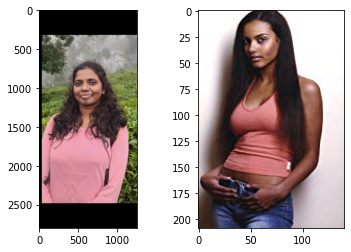

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import rcParams

%matplotlib inline

img_1 = mpimg.imread(original_image)
img_2 = mpimg.imread('/cxldata/projects/lookalikeceleb/images/' + matching_image)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_1);
ax[1].imshow(img_2);

print('Hey, you look line ' + os.path.splitext(matching_image)[0]+ '!')

In [4]:
# Face Recognition

# pre-requisite
# upload your image in ../lookalikeceleb/ with name 'myimage.jpg' <../lookalikeceleb/myimage.jpg>

import face_recognition  # python library for face detection and face recognition. built on dlib & deep learning encoders.
#It can detect faces in images, find face locations, convert face to face embeddings & compare faces
import os # a standarad python module to interacts with os (files/folders/paths)
import numpy as np
from IPython.display import Image # ajupyter-only display tool. Instead of opening images in a new window, 
# diplayes images directly in the notebook output

def load_images(known_images_dir): 
# loads images from a directory, extracts face encodings, and returns encodings along with corresponding image names for face recognition.
    known_encodings = []
    known_images = []
    
    for file in os.listdir(known_images_dir): # gets all files in the folder
        filename = os.fsdecode(file) # Converts filename into a proper string, Useful when filenames have special characters
        # Safe way to handle OS-level filenames
        image = face_recognition.load_image_file(os.path.join(known_images_dir, filename)) #os.path.join() builds full file path,
        # load_image_file() reads the image, Image is converted into a NumPy array        
        enc = face_recognition.face_encodings(image) # Returns a list of face encodings (Each encoding = 128 numbers)
        # enc = [array([0.12, -0.33, ..., 0.88])]
        if len(enc) > 0: # Some images may:Have no face, Be blurred or invalid. This prevents errors
            known_encodings.append(enc[0])
            known_images.append(filename)
            
    return (known_encodings, known_images)  

def calculate_face_distance(known_encodings, known_images, unknown_img_path, cutoff=0.5, num_results=4):
# Given an unknown face image, compare it with known face encodings and return the most similar known image.
# cutoff → similarity threshold, num_results → number of matches
    image_to_test = face_recognition.load_image_file(unknown_img_path) # Reads the image file & converts it into a NumPy array
    image_to_test_encoding = face_recognition.face_encodings(image_to_test)[0]
    # Detects faces in the image, Extracts face encodings, [0] → assumes only one face
    face_distances = face_recognition.face_distance(known_encodings, image_to_test_encoding)
    # computes Euclidean distance between unknown face and each known face
    return (unknown_img_path, known_images[face_distances.argmin()])
    # face_distances.argmin() -> Finds index of smallest distance
    # known_images[face_distances.argmin()] -> Filename of most similar known image



/usr/local/anaconda/lib/python3.6/site-packages/PIL/Image.py:976: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


Hey, you look like Jessica Lucas!


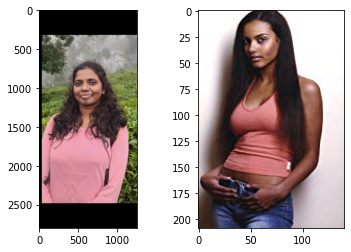

In [7]:
import matplotlib.pyplot as plt # plotting (figures, subplots)
import matplotlib.image as mpimg # reading image files into arrays
from matplotlib import rcParams # controls plot settings (not used here, but often used for size/fonts)

%matplotlib inline 
# Tells Jupyter: “Show plots inside the notebook, not in a separate window”. 
# This works only in Jupyter, not in .py files.

known_encodings, known_images = load_images("/cxldata/projects/lookalikeceleb/images")
# Reads all celebrity images & extracts face encodings and returns them with filename
original_image = "../lookalikeceleb/myimage.jpg"
Image(filename=original_image) # Displays your image in the notebook. No processing here, just visualization

matching_image = calculate_face_distance(known_encodings, known_images, original_image)[1]

img_1 = mpimg.imread(original_image) 
img_2 = mpimg.imread('/cxldata/projects/lookalikeceleb/images/' + matching_image)
# Reads image files, Converts them into NumPy arrays & Ready for plotting

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_1);
ax[1].imshow(img_2);
# Creates: 1 row & 2 columns - ax[0] → left image & ax[1] → right image
# (The semicolon suppresses extra output — optional)

print('Hey, you look like ' + os.path.splitext(matching_image)[0]+ '!')
# os.path.splitext() removes file extension: "actor.jpg" → "actor"